In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style="whitegrid")


df = pd.read_csv('startup_success_dataset.csv')

num_cols = ['funding_rounds', 'founder_experience_years', 'team_size', 
            'market_size_billion', 'product_traction_users', 
            'burn_rate_million', 'revenue_million']
cat_cols = ['investor_type', 'sector', 'founder_background']

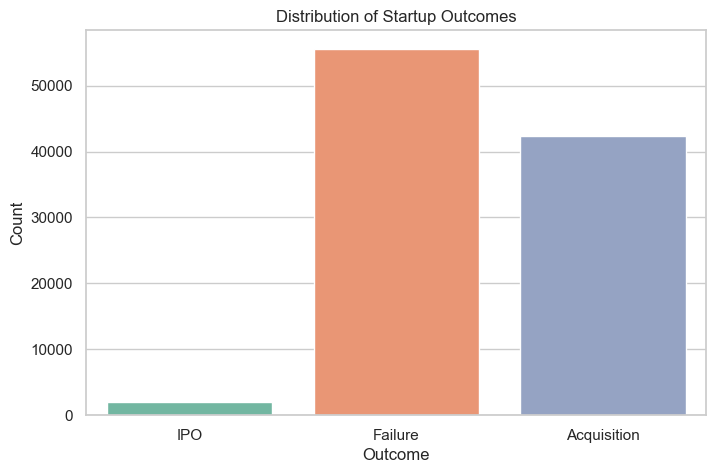

In [2]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(data=df, x='outcome', hue='outcome', palette='Set2', legend=False)

plt.title('Distribution of Startup Outcomes')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

C:\Users\MinhDuc\AppData\Local\Temp\ipykernel_16856\1042773537.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0,0], data=df, x='outcome', y='burn_rate_million', palette='Set2')
C:\Users\MinhDuc\AppData\Local\Temp\ipykernel_16856\1042773537.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0,1], data=df, x='outcome', y='revenue_million', palette='Set2')
C:\Users\MinhDuc\AppData\Local\Temp\ipykernel_16856\1042773537.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1,0], data=df, x='outcome', y='founder_experi

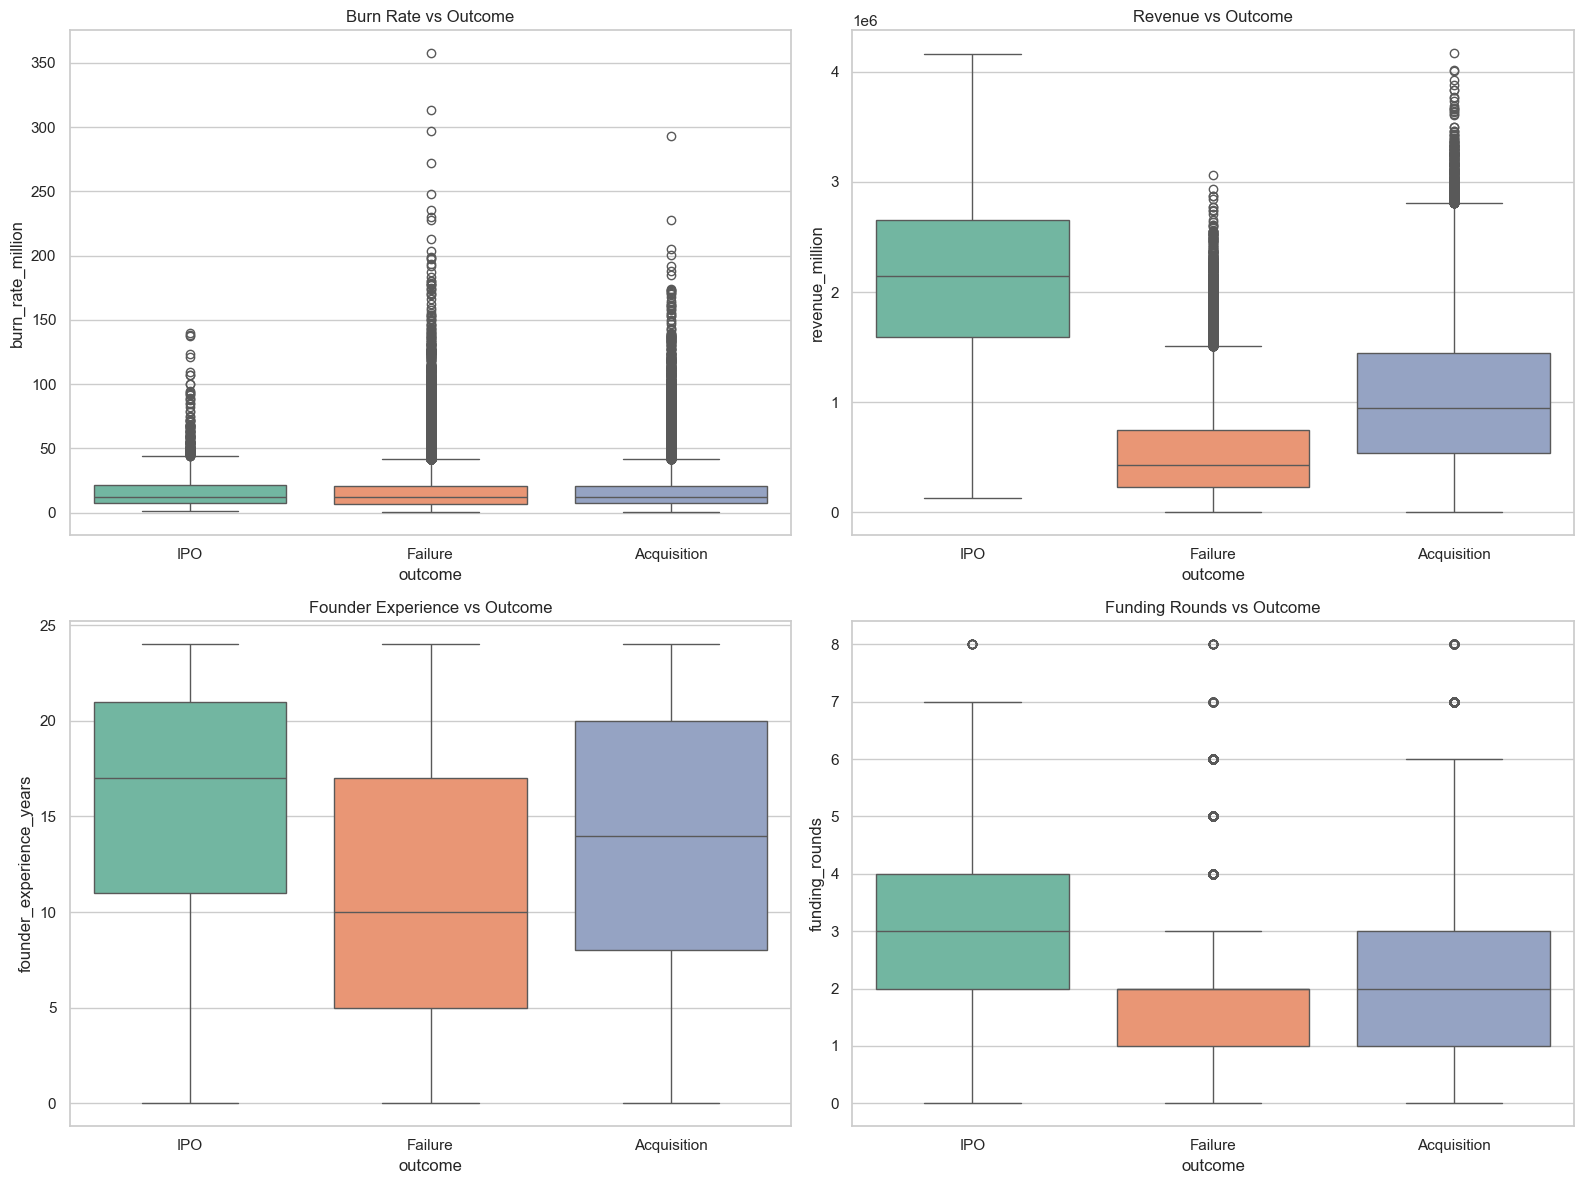

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Burn Rate vs Outcome
sns.boxplot(ax=axes[0,0], data=df, x='outcome', y='burn_rate_million', palette='Set2')
axes[0,0].set_title('Burn Rate vs Outcome')

# 2. Revenue vs Outcome
sns.boxplot(ax=axes[0,1], data=df, x='outcome', y='revenue_million', palette='Set2')
axes[0,1].set_title('Revenue vs Outcome')

# 3. Founder Experience vs Outcome
sns.boxplot(ax=axes[1,0], data=df, x='outcome', y='founder_experience_years', palette='Set2')
axes[1,0].set_title('Founder Experience vs Outcome')

# 4. Funding Rounds vs Outcome
sns.boxplot(ax=axes[1,1], data=df, x='outcome', y='funding_rounds', hue='outcome', palette='Set2', legend=False)
axes[1,1].set_title('Funding Rounds vs Outcome')

plt.tight_layout()
plt.show()

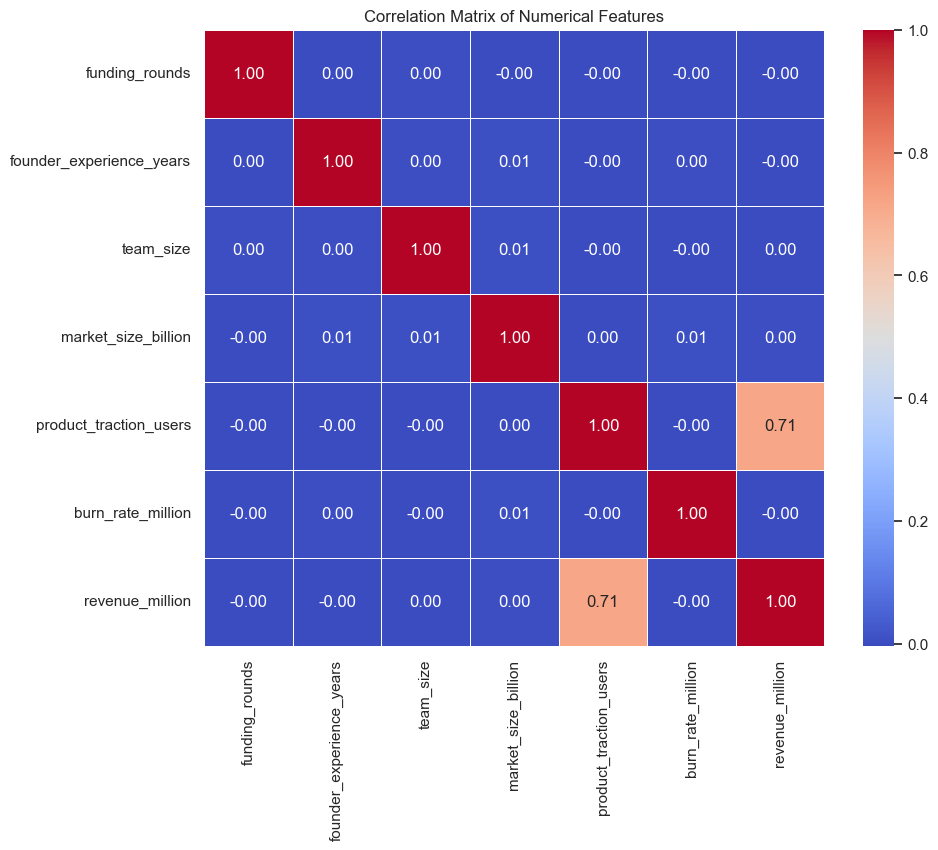

In [4]:
plt.figure(figsize=(10, 8))
correlation_matrix = df[num_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

C:\Users\MinhDuc\AppData\Local\Temp\ipykernel_16856\3843812104.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='MI_Score', y='Feature', data=mi_scores_df, palette='viridis')


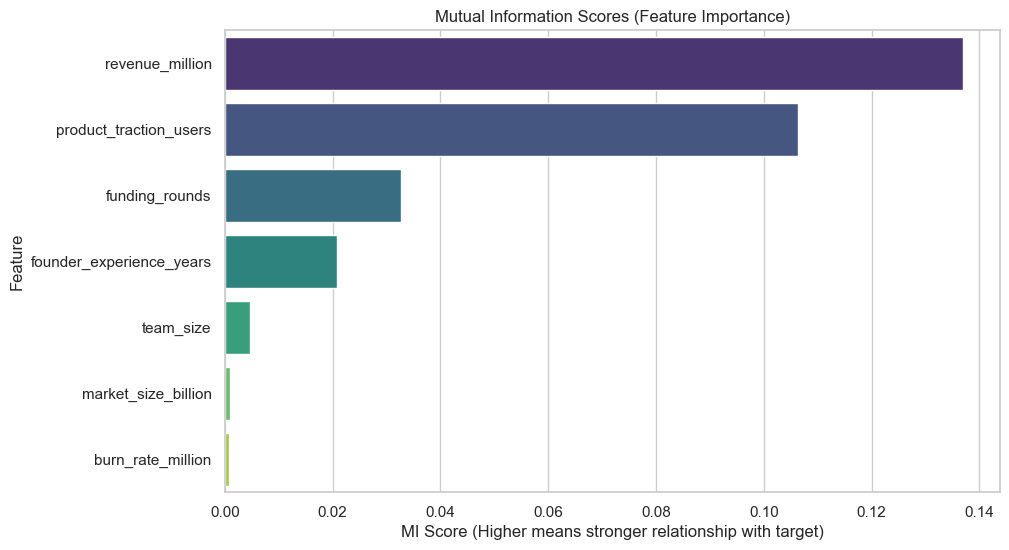

In [ ]:
X_num = df[num_cols].fillna(0) 
y_target = df['outcome']

# Calculate MI scores
mi_scores = mutual_info_classif(X_num, y_target, random_state=42)

# Create a DataFrame for visualization
mi_scores_df = pd.DataFrame({'Feature': num_cols, 'MI_Score': mi_scores})
mi_scores_df = mi_scores_df.sort_values(by='MI_Score', ascending=False)

# Visualize MI Scores
plt.figure(figsize=(10, 6))
sns.barplot(x='MI_Score', y='Feature', data=mi_scores_df, palette='viridis')
plt.title('Mutual Information Scores (Feature Importance)')
plt.xlabel('MI Score (Higher means stronger relationship with target)')
plt.ylabel('Feature')
plt.show()